In [1]:
import pandas as pd

df = pd.read_csv("online_retail_II.csv")
print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
df = df.dropna(subset=["Customer ID"])                 # remove rows with no customer
df = df[~df["Invoice"].astype(str).str.startswith("C")] # remove cancelled orders
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]       # remove wrong values
df = df.drop_duplicates()                               # remove repeated rows

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Customer ID"] = df["Customer ID"].astype(int)
df["TotalPrice"] = df["Quantity"] * df["Price"]         # money spent per row

print(df.shape)
df.to_csv("clean_sales.csv", index=False)

(779425, 9)


In [3]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])  # reduce extreme values
X = StandardScaler().fit_transform(X)                     # put numbers on the same scale

km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = km.fit_predict(X)

rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)

,Recency,Frequency,Monetary
Cluster,,,
0,394.9,1.4,317.1
1,28.3,3.1,857.5
2,27.7,19.3,10731.2
3,230.1,5.1,1948.5


In [5]:
names = {0: "Champions", 1: "Loyal", 2: "At Risk", 3: "Lost"}   # CHANGE this to match your table
rfm["Segment"] = rfm["Cluster"].map(names)
rfm["Segment"].value_counts()

,count
Segment,
Champions,1973
Lost,1459
Loyal,1250
At Risk,1196


In [6]:
rfm.to_csv("customer_segments.csv", index=False)

from google.colab import files
files.download("customer_segments.csv")
files.download("clean_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

InvoiceDate
2009-12-01     683504.010
2010-01-01     555802.672
2010-02-01     504558.956
2010-03-01     696978.471
2010-04-01     591982.002
2010-05-01     597833.380
2010-06-01     636371.130
2010-07-01     589736.170
2010-08-01     602224.600
2010-09-01     829013.951
2010-10-01    1033112.010
2010-11-01    1166460.022
2010-12-01     570422.730
2011-01-01     568101.310
2011-02-01     446084.920
2011-03-01     594081.760
2011-04-01     468374.331
2011-05-01     677355.150
2011-06-01     660046.050
2011-07-01     598962.901
2011-08-01     644051.040
2011-09-01     950690.202
2011-10-01    1035642.450
2011-11-01    1156205.610
Freq: MS, Name: TotalPrice, dtype: float64


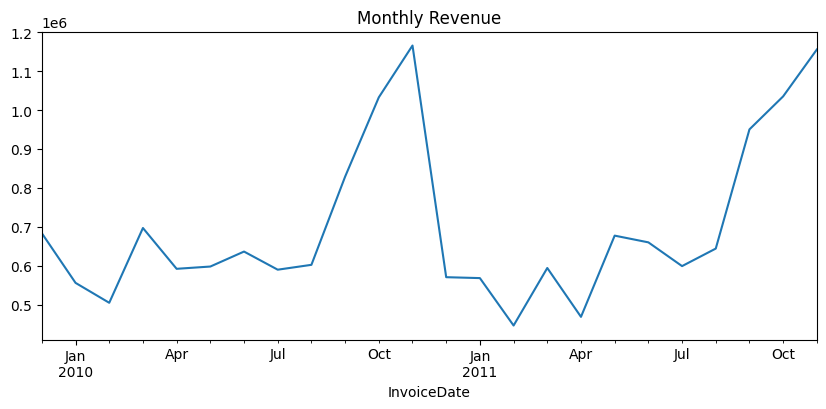

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv("clean_sales.csv", parse_dates=["InvoiceDate"])
monthly = df.set_index("InvoiceDate")["TotalPrice"].resample("MS").sum()
monthly = monthly.iloc[:-1]
print(monthly)
monthly.plot(figsize=(10,4), title="Monthly Revenue")
plt.show()

In [10]:
train, test = monthly[:-3], monthly[-3:]

model = ExponentialSmoothing(train, trend="add", seasonal="add",
                             seasonal_periods=6,
                             initialization_method="estimated").fit()
pred = model.forecast(3)

mae = np.mean(np.abs(test - pred))
mape = np.mean(np.abs((test - pred) / test)) * 100
print("MAE:", round(mae), " MAPE:", round(mape, 1), "%")

MAE: 168866  MAPE: 15.9 %


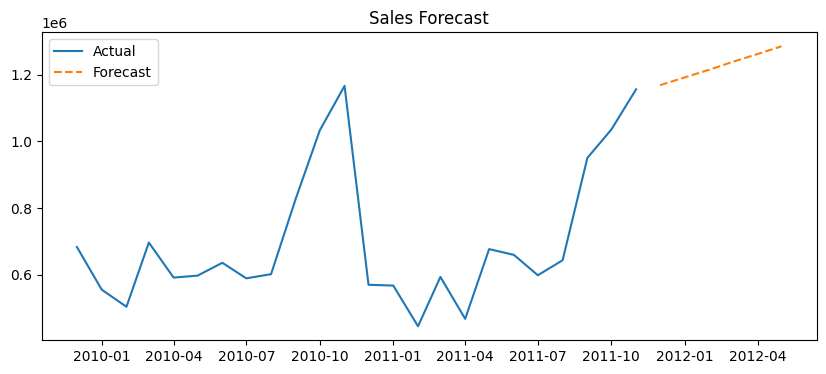

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
final = ExponentialSmoothing(monthly, trend="add").fit()
future = final.forecast(6)
err = np.std(final.resid)

history = pd.DataFrame({"Date": monthly.index, "Actual": monthly.values,
                        "Forecast": final.fittedvalues.values})
ahead = pd.DataFrame({"Date": future.index, "Actual": np.nan,
                      "Forecast": future.values,
                      "Lower": future.values - 1.96*err,
                      "Upper": future.values + 1.96*err})
out = pd.concat([history, ahead], ignore_index=True)
out.to_csv("sales_forecast.csv", index=False)

plt.figure(figsize=(10,4))
plt.plot(monthly, label="Actual")
plt.plot(future, label="Forecast", linestyle="--")
plt.legend(); plt.title("Sales Forecast"); plt.show()

from google.colab import files
files.download("sales_forecast.csv")